# QGAIN v3.1.0 - gain and recorded-level dynamics

**Scientific question.** What is the typical recorded strict-speech level,
how variable is it within and between speech segments, and does it drift
systematically over the recording?

QGAIN is a four-feature profile, not a scalar quality score and not an AGC
detector. Its measurements can reflect device gain, platform processing,
microphone distance, handling, vocal intensity, prosody, respiration, or
dysarthria. Causal attribution is outside the extraction claim.

QGAIN v3.1 removes the v3.0 local-transition rate from the analysis
profile. Real-speech validation showed that it responded frequently to
ordinary phonetic and prosodic level transitions. Its candidate ledger is
retained only as a traceable negative-result audit and is never exported
as a manuscript feature.

The authoritative estimator is `paper1_qc.qgain`. This notebook supplies
measurement-science validation, frozen-cohort extraction, audit ledgers,
publication figures, reviewer galleries, and an immutable freeze gate.
Human-QC correspondence and ALS associations are downstream analyses.


## 0. Environment, controls, and common output contract


In [1]:
from __future__ import annotations

from dataclasses import replace
from pathlib import Path
from tempfile import TemporaryDirectory
import json
import math
import shutil
import subprocess
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
from scipy import stats
from IPython.display import Markdown, display
import yaml


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "paper1_qc").exists():
            return candidate
    raise FileNotFoundError("Open this notebook from inside the paper1 repository.")


ROOT = find_project_root()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from paper1_qc.feature_validation import (
    OKABE_ITO,
    ValidationCheck,
    gate_passed,
    save_publication_figure,
    save_table_bundle,
    set_publication_style,
    sha256_file,
    validation_frame,
    write_json,
)
from paper1_qc.media import decode_audio_views
from paper1_qc.qgain import (
    ANALYSIS_FEATURES,
    DEFAULT_PARAMETERS,
    FEATURE_DEFINITIONS,
    MEASUREMENT_VERSION,
    PRIMARY_FEATURES,
    TimeInterval,
    apply_gain_db,
    apply_level_envelope_db,
    extract_qgain,
    feature_registry_frame,
    guarded_speech_intervals,
)

warnings.filterwarnings("default")
pd.set_option("display.max_columns", 220)
pd.set_option("display.width", 220)
set_publication_style()

CONFIG = ROOT / "config" / "project.yaml"
MAIN_OUTPUTS = ROOT / "MAIN outputs"
STAGE = ROOT / "outputs" / "02_features" / "gain_dynamics" / MEASUREMENT_VERSION
TABLES = STAGE / "tables"
FIGURES = STAGE / "figures"
GALLERY = STAGE / "gallery"
AUDIT = STAGE / "audit"
for directory in [TABLES, FIGURES, GALLERY, AUDIT]:
    directory.mkdir(parents=True, exist_ok=True)

RUN_COHORT_EXTRACTION = True
RUN_CODEC_ROUNDTRIP = True
RUN_PACKAGE_TESTS = True
PACKAGE_TESTS_CONFIRMED = False
BUILD_GALLERY = True
MAX_ROBUSTNESS_RECORDINGS = 60

# This final v3.1 run freezes only if every blocking validation passes.
PUBLISH_AND_FREEZE_QGAIN_V31 = True
PACKAGE_INTEGRATION_APPROVED = False
QGAIN_REVIEW_DECISION = "ACCEPT_QGAIN_V31"
QGAIN_REVIEWER = "Nevena Musikic"
QGAIN_REVIEW_RATIONALE = (
    "Accepted the four-feature recorded-level profile after QGAIN v3.0 "
    "technical, synthetic, codec, robustness, empirical-distribution, "
    "and gallery review. The invalid local-transition rate was removed "
    "from analysis and retained only as an explicitly rejected audit."
)

PARAMETERS = DEFAULT_PARAMETERS
FS = PARAMETERS.analysis_sample_rate_hz
RNG = np.random.default_rng(PARAMETERS.random_seed)

print("Project:", ROOT)
print("Measurement:", MEASUREMENT_VERSION)
print("Cohort extraction:", RUN_COHORT_EXTRACTION)
print("Outputs:", STAGE)


Project: C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1
Measurement: qgain-v3.1.0
Cohort extraction: True
Outputs: C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\outputs\02_features\gain_dynamics\qgain-v3.1.0


## 1. Immutable feature registry and scientific claim boundaries


In [2]:
feature_registry = feature_registry_frame()
save_table_bundle(feature_registry, TABLES, "qgain_v31_feature_registry")
save_table_bundle(
    pd.DataFrame(
        [{"parameter": key, "value": json.dumps(value) if isinstance(value, (list, dict)) else value}
         for key, value in PARAMETERS.to_dict().items()]
    ),
    TABLES,
    "qgain_v31_parameters",
)
write_json(PARAMETERS.to_dict(), AUDIT / "qgain_v31_parameters.json")

registry_checks = validation_frame([
    ValidationCheck("registry", "exactly four prespecified analysis features",
                    tuple(feature_registry["name"]) == tuple(ANALYSIS_FEATURES),
                    str(feature_registry["name"].tolist()), str(list(ANALYSIS_FEATURES)),
                    "repair registry/package mismatch"),
    ValidationCheck("registry", "no scalar QGAIN score",
                    not feature_registry["name"].str.contains("composite|burden|qgain_score").any(),
                    "absent", "absent", "remove scalar construct"),
    ValidationCheck("registry", "rejected transition metric is excluded",
                    not feature_registry["name"].str.contains(
                        "step|transition", case=False, regex=True
                    ).any(),
                    "absent", "absent", "remove rejected metric"),
])
display(feature_registry)
display(registry_checks)


,name,display_name,subdomain,role,unit,estimand,orientation,claim_boundary,minimum_support,known_confounds
0,qgain_typical_speech_level_dbfs,Typical strict-speech operating level,operating level,contextual,dBFS,Median AC-RMS level of guarded strict-speech f...,Higher is closer to digital full scale; not or...,Not ITU-T P.56 active speech level and not cal...,At least 1.0 s guarded speech and 25 non-floor...,"Vocal intensity, dysarthria, distance, task, d..."
1,qgain_within_segment_iqr_db,Within-segment centered level IQR,short-term dynamics,primary,dB,IQR after subtracting each segment's median fr...,Higher indicates greater within-segment level ...,Compatible with gain modulation but not specif...,"At least 1.0 s guarded speech, 25 frames, and ...","Prosody, phonetic composition, respiratory con..."
2,qgain_between_segment_mad_db,Between-segment level MAD,segment dynamics,primary,dB,1.4826 times MAD of usable segment-median levels.,Higher indicates larger segment-level shifts.,Within-recording variability; not a pure devic...,At least three usable speech segments.,"Sentence content, fatigue, posture, distance, ..."
3,qgain_abs_drift_db_per_min,Absolute robust level drift,slow dynamics,primary,dB/min,Absolute Theil-Sen slope of segment level agai...,Higher indicates faster gradual level change.,Compatible with changing gain or distance but ...,At least three segments spanning at least 10 s.,"Fatigue, intentional loudness, respiration, po..."


,layer,check,passed,observed,required,action_if_failed,blocking
0,registry,exactly four prespecified analysis features,True,"['qgain_typical_speech_level_dbfs', 'qgain_wit...","['qgain_typical_speech_level_dbfs', 'qgain_wit...",repair registry/package mismatch,True
1,registry,no scalar QGAIN score,True,absent,absent,remove scalar construct,True
2,registry,rejected transition metric is excluded,True,absent,absent,remove rejected metric,True


### Operational definitions

For guarded strict-speech frame \(t\) in segment \(s\), the framewise
AC-RMS level is

\[
L_{s,t}=20\log_{10}\left[
\sqrt{\frac{1}{N}\sum_{n=1}^{N}(x_n-\bar{x})^2}
\right].
\]

The contextual operating level is \(\mathrm{median}(L_{s,t})\).
Within-segment dispersion is the pooled IQR after subtracting each
segment median. Between-segment dispersion is
\(1.4826\,\mathrm{median}|M_s-\mathrm{median}(M_s)|\), where \(M_s\)
is a usable segment median. Absolute drift is 60 times the absolute
Theil-Sen slope of \(M_s\) against original recording seconds.

These are study-specific robust estimators. The operating-level feature
is not labeled ITU-T P.56 active speech level because the P.56 algorithm
is not implemented. Literature supports the acquisition dependence and
fit-for-purpose validation problem, not the exact study thresholds:
ITU-T P.56 (2011); Titze and Winholtz (1993,
doi:10.1044/jshr.3606.1177); Zhang et al. (2021,
doi:10.1121/10.0005132); Goldsack et al. (2020,
doi:10.1038/s41746-020-0260-4).


## 2. Deterministic formula and transform validation

The operating-level feature must shift one-for-one under unclipped digital
gain. Dispersion and drift magnitude must remain invariant.
The control avoids clipping and threshold-crossing support changes.


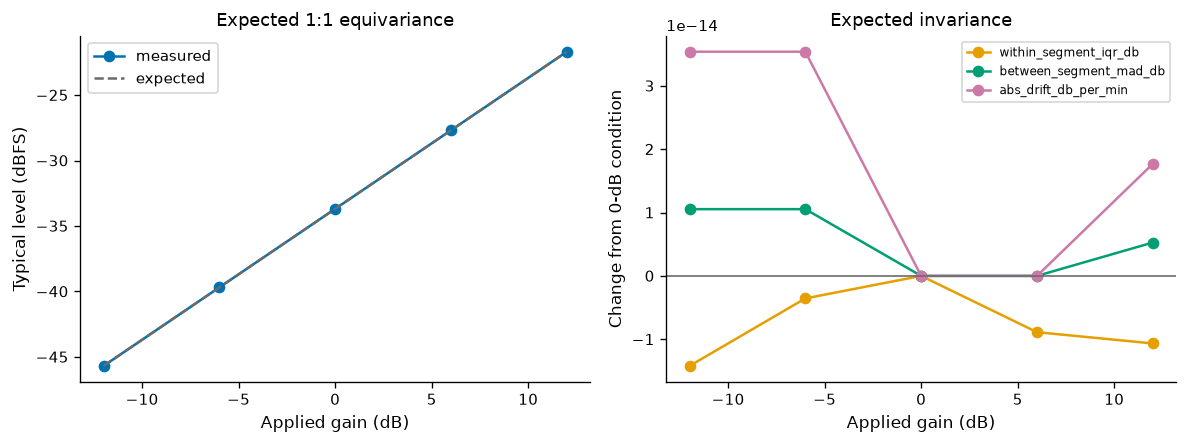

,layer,check,passed,observed,required,action_if_failed,blocking
0,formula,typical level has 1:1 gain equivariance,True,7.105e-15 dB,<1e-9 dB,repair dBFS estimator,True
1,formula,dynamic features are gain invariant,True,3.538e-14,<1e-9,repair centering/trend estimator,True


In [3]:
def synthetic_carrier(duration_sec=18.0, amplitude=0.025):
    time = np.arange(int(round(duration_sec * FS))) / FS
    waveform = amplitude * (
        np.sin(2*np.pi*173*time)
        + 0.55*np.sin(2*np.pi*421*time + 0.3)
        + 0.25*np.sin(2*np.pi*911*time + 0.7)
    )
    third = duration_sec / 3
    intervals = [
        TimeInterval(0.0, third - 0.05),
        TimeInterval(third + 0.05, 2*third - 0.05),
        TimeInterval(2*third + 0.05, duration_sec),
    ]
    return waveform, intervals


base_waveform, synthetic_intervals = synthetic_carrier()
gain_rows = []
for gain_db in [-12, -6, 0, 6, 12]:
    extraction = extract_qgain(
        apply_gain_db(base_waveform, gain_db), FS,
        strict_speech=synthetic_intervals, logical_recording_id=f"gain_{gain_db}",
    )
    gain_rows.append({"applied_gain_db": gain_db, **{
        feature: extraction.recording[feature] for feature in ANALYSIS_FEATURES
    }})
gain_controls = pd.DataFrame(gain_rows)
baseline = gain_controls.loc[gain_controls["applied_gain_db"].eq(0)].iloc[0]
gain_deltas = gain_controls.copy()
for feature in ANALYSIS_FEATURES:
    gain_deltas[feature] = gain_controls[feature] - baseline[feature]

expected_level = (
    baseline["qgain_typical_speech_level_dbfs"]
    + gain_controls["applied_gain_db"]
)
level_error = np.max(np.abs(
    gain_controls["qgain_typical_speech_level_dbfs"] - expected_level
))
invariant_features = [
    "qgain_within_segment_iqr_db",
    "qgain_between_segment_mad_db",
    "qgain_abs_drift_db_per_min",
]
invariant_error = max(
    float(np.nanmax(np.abs(gain_deltas[feature])))
    for feature in invariant_features
)
formula_checks = validation_frame([
    ValidationCheck("formula", "typical level has 1:1 gain equivariance",
                    level_error < 1e-9, f"{level_error:.3e} dB", "<1e-9 dB",
                    "repair dBFS estimator"),
    ValidationCheck("formula", "dynamic features are gain invariant",
                    invariant_error < 1e-9, f"{invariant_error:.3e}", "<1e-9",
                    "repair centering/trend estimator"),
])
save_table_bundle(gain_controls, TABLES, "qgain_v31_deterministic_gain_controls")
save_table_bundle(formula_checks, TABLES, "qgain_v31_formula_checks")

fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.8))
axes[0].plot(gain_controls["applied_gain_db"],
             gain_controls["qgain_typical_speech_level_dbfs"],
             "o-", color=OKABE_ITO["blue"], label="measured")
axes[0].plot(gain_controls["applied_gain_db"], expected_level,
             "--", color=OKABE_ITO["grey"], label="expected")
axes[0].set(xlabel="Applied gain (dB)", ylabel="Typical level (dBFS)",
            title="Expected 1:1 equivariance")
axes[0].legend()
for feature, color in zip(invariant_features, [
    OKABE_ITO["orange"], OKABE_ITO["green"], OKABE_ITO["purple"]
]):
    axes[1].plot(gain_deltas["applied_gain_db"], gain_deltas[feature],
                 "o-", label=feature.replace("qgain_", ""), color=color)
axes[1].axhline(0, color=OKABE_ITO["grey"], linewidth=1)
axes[1].set(xlabel="Applied gain (dB)", ylabel="Change from 0-dB condition",
            title="Expected invariance")
axes[1].legend(fontsize=7)
fig.tight_layout()
save_publication_figure(
    fig, FIGURES, "figure_qgain_formula_transform_validation",
    caption=("QGAIN v3.1 deterministic transform validation. Typical speech level "
             "tracks unclipped digital gain one-for-one; level-dynamics features "
             "remain invariant when support is unchanged."),
    alt_text=("Two panels show exact gain equivariance of typical speech level "
              "and invariance of three level-dynamics descriptors."),
)
plt.show()
display(formula_checks)


## 3. Synthetic construct validity and discriminant controls


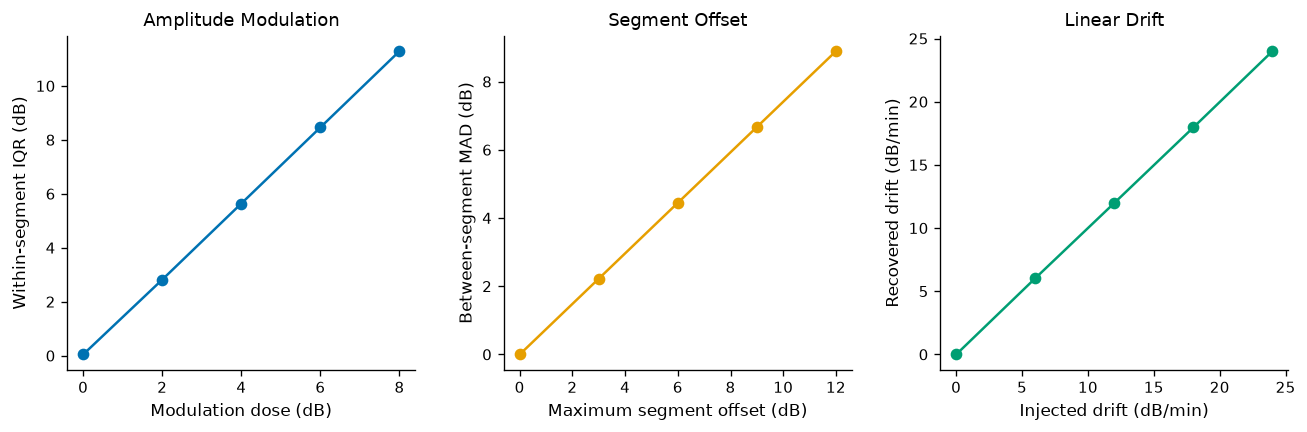

,layer,check,passed,observed,required,action_if_failed,blocking
0,construct,within-segment IQR orders modulation dose,True,checked,monotonic,repair centered-IQR estimator,True
1,construct,between-segment MAD orders offset dose,True,checked,monotonic,repair segment estimator,True
2,construct,drift recovers imposed dB/min,True,checked,<0.25 dB/min,repair time/trend estimator,True


In [4]:
time = np.arange(len(base_waveform)) / FS
mechanism_rows = []

for dose in [0, 2, 4, 6, 8]:
    waveform = apply_level_envelope_db(
        base_waveform, dose * np.sin(2*np.pi*0.7*time)
    )
    value = extract_qgain(
        waveform, FS, strict_speech=synthetic_intervals,
        logical_recording_id=f"am_{dose}",
    ).recording
    mechanism_rows.append({
        "mechanism": "amplitude_modulation",
        "dose": dose,
        "response": value["qgain_within_segment_iqr_db"],
    })

for dose in [0, 3, 6, 9, 12]:
    envelope = np.zeros(len(base_waveform))
    envelope[int(6*FS):int(12*FS)] = dose / 2
    envelope[int(12*FS):] = dose
    value = extract_qgain(
        apply_level_envelope_db(base_waveform, envelope), FS,
        strict_speech=synthetic_intervals,
        logical_recording_id=f"offset_{dose}",
    ).recording
    mechanism_rows.append({
        "mechanism": "segment_offset",
        "dose": dose,
        "response": value["qgain_between_segment_mad_db"],
    })

for dose in [0, 6, 12, 18, 24]:
    ramp_db = dose * time / 60.0
    value = extract_qgain(
        apply_level_envelope_db(base_waveform, ramp_db), FS,
        strict_speech=synthetic_intervals,
        logical_recording_id=f"drift_{dose}",
    ).recording
    mechanism_rows.append({
        "mechanism": "linear_drift",
        "dose": dose,
        "response": value["qgain_abs_drift_db_per_min"],
    })

mechanism_dose = pd.DataFrame(mechanism_rows)

mechanism_checks = validation_frame([
    ValidationCheck("construct", "within-segment IQR orders modulation dose",
                    mechanism_dose.loc[
                        mechanism_dose["mechanism"].eq("amplitude_modulation"),
                        "response"
                    ].is_monotonic_increasing,
                    "checked", "monotonic", "repair centered-IQR estimator"),
    ValidationCheck("construct", "between-segment MAD orders offset dose",
                    mechanism_dose.loc[
                        mechanism_dose["mechanism"].eq("segment_offset"),
                        "response"
                    ].is_monotonic_increasing,
                    "checked", "monotonic", "repair segment estimator"),
    ValidationCheck("construct", "drift recovers imposed dB/min",
                    np.max(np.abs(
                        mechanism_dose.loc[
                            mechanism_dose["mechanism"].eq("linear_drift"), "response"
                        ].to_numpy()
                        - mechanism_dose.loc[
                            mechanism_dose["mechanism"].eq("linear_drift"), "dose"
                        ].to_numpy()
                    )) < 0.25,
                    "checked", "<0.25 dB/min", "repair time/trend estimator"),
])
save_table_bundle(mechanism_dose, TABLES, "qgain_v31_mechanism_dose_response")
save_table_bundle(mechanism_checks, TABLES, "qgain_v31_mechanism_checks")

fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.7))
specifications = [
    ("amplitude_modulation", "Within-segment IQR (dB)", "Modulation dose (dB)"),
    ("segment_offset", "Between-segment MAD (dB)", "Maximum segment offset (dB)"),
    ("linear_drift", "Recovered drift (dB/min)", "Injected drift (dB/min)"),
]
for ax, (mechanism, ylabel, xlabel), color in zip(
    axes.flat, specifications,
    [OKABE_ITO["blue"], OKABE_ITO["orange"], OKABE_ITO["green"]]
):
    local = mechanism_dose.loc[mechanism_dose["mechanism"].eq(mechanism)]
    ax.plot(local["dose"], local["response"], "o-", color=color)
    ax.set(xlabel=xlabel, ylabel=ylabel, title=mechanism.replace("_", " ").title())
fig.tight_layout()
save_publication_figure(
    fig, FIGURES, "figure_qgain_synthetic_construct_validity",
    caption=("Prespecified QGAIN v3.1 synthetic construct controls: amplitude "
             "modulation, segment-specific offsets, and linear dB drift are "
             "varied independently."),
    alt_text=("Three dose-response panels show the expected response of each "
              "QGAIN level-dynamics estimator."),
)
plt.show()
display(mechanism_checks)


## 4. Digital-floor censoring calibration

Digital-floor frames are not ordinary low-amplitude speech. They are excluded,
audited, and the recording is censored if more than 2% of strict-speech frames
are floor affected.


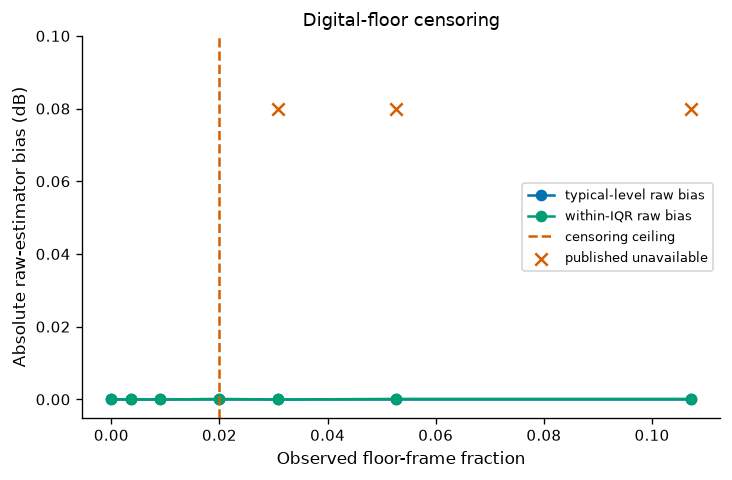

,layer,check,passed,observed,required,action_if_failed,blocking
0,floor,clean signal remains available,True,False,False,repair floor detector,True
1,floor,mixtures above configured ceiling are censored,True,checked,all censored,repair censoring policy,True


In [5]:
floor_rows = []
for fraction in [0.0, 0.005, 0.01, 0.02, 0.03, 0.05, 0.10]:
    waveform = base_waveform.copy()
    center = len(waveform) // 2
    width = int(round(fraction * len(waveform)))
    waveform[center:center+width] = 0.0
    result = extract_qgain(
        waveform, FS, strict_speech=synthetic_intervals,
        logical_recording_id=f"floor_{fraction}",
    ).recording
    floor_rows.append({
        "injected_fraction": fraction,
        "observed_floor_fraction": result["qgain_floor_frame_fraction"],
        "floor_censored": result["qgain_floor_censored"],
        "typical_raw_estimate": result[
            "qgain_typical_speech_level_dbfs_raw_estimate"
        ],
        "within_raw_estimate": result[
            "qgain_within_segment_iqr_db_raw_estimate"
        ],
        **{feature: result[feature] for feature in ANALYSIS_FEATURES},
    })
floor_calibration = pd.DataFrame(floor_rows)
floor_checks = validation_frame([
    ValidationCheck("floor", "clean signal remains available",
                    not bool(floor_calibration.iloc[0]["floor_censored"]),
                    str(floor_calibration.iloc[0]["floor_censored"]), "False",
                    "repair floor detector"),
    ValidationCheck("floor", "mixtures above configured ceiling are censored",
                    floor_calibration.loc[
                        floor_calibration["observed_floor_fraction"]
                        > PARAMETERS.maximum_floor_frame_fraction,
                        "floor_censored",
                    ].astype(bool).all(),
                    "checked", "all censored", "repair censoring policy"),
])
save_table_bundle(floor_calibration, TABLES, "qgain_v31_floor_censoring_calibration")
save_table_bundle(floor_checks, TABLES, "qgain_v31_floor_censoring_checks")

fig, ax = plt.subplots(figsize=(6.2, 4.1))
clean_typical = floor_calibration.iloc[0]["typical_raw_estimate"]
clean_within = floor_calibration.iloc[0]["within_raw_estimate"]
ax.plot(
    floor_calibration["observed_floor_fraction"],
    np.abs(floor_calibration["typical_raw_estimate"] - clean_typical),
    "o-", color=OKABE_ITO["blue"], label="typical-level raw bias",
)
ax.plot(
    floor_calibration["observed_floor_fraction"],
    np.abs(floor_calibration["within_raw_estimate"] - clean_within),
    "o-", color=OKABE_ITO["green"], label="within-IQR raw bias",
)
ax.axvline(PARAMETERS.maximum_floor_frame_fraction,
           color=OKABE_ITO["vermillion"], linestyle="--",
           label="censoring ceiling")
censored = floor_calibration.loc[
    floor_calibration["floor_censored"].astype(bool)
]
ax.scatter(
    censored["observed_floor_fraction"],
    np.full(len(censored), 0.08),
    marker="x", s=55, color=OKABE_ITO["vermillion"],
    label="published unavailable",
)
ax.set(xlabel="Observed floor-frame fraction",
       ylabel="Absolute raw-estimator bias (dB)",
       ylim=(-0.005, 0.10),
       title="Digital-floor censoring")
ax.legend(fontsize=8)
fig.tight_layout()
save_publication_figure(
    fig, FIGURES, "figure_qgain_floor_censoring_calibration",
    caption=("QGAIN v3.1 digital-floor calibration. Raw-estimator bias is "
             "shown as floor contamination increases; published features "
             "are unavailable beyond the prespecified ceiling."),
    alt_text=("Feature bias and censoring status as the fraction of "
              "digital-floor frames increases."),
)
plt.show()
display(floor_checks)


## 5. Frozen input and provenance contract


In [6]:
def _table_file(stem: Path) -> Path:
    if stem.suffix.lower() in {".csv", ".parquet"} and stem.exists():
        return stem
    for suffix in [".parquet", ".csv"]:
        candidate = stem.with_suffix(suffix)
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Missing table: {stem}")


def read_table(stem: Path) -> pd.DataFrame:
    path = _table_file(stem)
    return pd.read_parquet(path) if path.suffix.lower() == ".parquet" else pd.read_csv(path)


def as_bool(series: pd.Series) -> pd.Series:
    return series.map(lambda value: value if isinstance(value, bool)
                      else str(value).strip().lower() in {"1", "true", "yes", "y"})


def discover_interval_table(folder: Path):
    candidates, seen = [], set()
    for path in sorted(folder.rglob("*")):
        if path.suffix.lower() not in {".csv", ".parquet"}:
            continue
        stem = path.with_suffix("")
        if stem in seen and path.suffix.lower() == ".csv":
            continue
        seen.add(stem)
        try:
            frame = read_table(path)
        except Exception:
            continue
        columns = set(frame.columns)
        if not ({"start_sec", "end_sec"}.issubset(columns)
                or {"start", "end"}.issubset(columns)):
            continue
        if not {"view", "segment_type", "label", "region"}.intersection(columns):
            continue
        if not {"logical_recording_id", "file_name"}.intersection(columns):
            continue
        score = (8*("frozen" in path.stem.lower())
                 + 6*("interval" in path.stem.lower())
                 + 2*(path.suffix.lower() == ".parquet"))
        candidates.append((score, path, frame))
    if not candidates:
        raise FileNotFoundError(f"No frozen interval table under {folder}")
    candidates.sort(key=lambda item: (-item[0], str(item[1])))
    if len(candidates) > 1 and candidates[0][0] == candidates[1][0]:
        raise RuntimeError("Tied interval-table candidates; resolve upstream.")
    return candidates[0][1], candidates[0][2]


def load_frozen_inputs():
    cfg = yaml.safe_load(CONFIG.read_text(encoding="utf-8"))
    segmentation_version = str(cfg.get("segmentation_freeze", {}).get(
        "version", cfg.get("data_freeze", {}).get("version", "v1")
    ))
    data_version = str(cfg.get("data_freeze", {}).get("version", "v1"))
    segmentation_folder = MAIN_OUTPUTS / "01_SEGMENTATION_FREEZE" / segmentation_version
    data_folder = MAIN_OUTPUTS / "00_DATA_FREEZE" / data_version
    decisions_path = _table_file(segmentation_folder / "frozen_segmentation_decisions")
    recordings_path = _table_file(data_folder / "frozen_bamboo_recordings")
    intervals_path, intervals = discover_interval_table(segmentation_folder)
    decisions, recordings = read_table(decisions_path), read_table(recordings_path)
    if "segmentation_analysis_eligible" not in decisions:
        raise ValueError("Frozen decisions lack segmentation_analysis_eligible")
    eligible = decisions.loc[as_bool(decisions["segmentation_analysis_eligible"])].copy()
    if "logical_recording_id" not in intervals:
        mapping = decisions[["file_name", "logical_recording_id"]].drop_duplicates()
        if mapping["file_name"].duplicated().any():
            raise ValueError("file_name is not unique in frozen decisions")
        intervals = intervals.merge(mapping, on="file_name", how="left", validate="many_to_one")
    for frame in [eligible, recordings, intervals]:
        frame["logical_recording_id"] = frame["logical_recording_id"].astype(str)
    media_column = next((column for column in [
        "media_path", "selected_media_path", "file_path", "selected_path"
    ] if column in recordings), None)
    if media_column is None:
        raise ValueError("Frozen recording table lacks selected media path")
    recordings = recordings.rename(columns={media_column: "media_path"})
    analysis_recordings = eligible[["logical_recording_id"]].merge(
        recordings.drop_duplicates("logical_recording_id"),
        on="logical_recording_id", how="left", validate="one_to_one",
    )
    intervals = intervals.rename(columns={"start": "start_sec", "end": "end_sec"})
    view_column = next((column for column in [
        "view", "segment_type", "label", "region"
    ] if column in intervals), None)
    intervals = intervals.rename(columns={view_column: "view"})
    if "profile" in intervals and intervals["profile"].astype(str).eq("primary").any():
        intervals = intervals.loc[intervals["profile"].astype(str).eq("primary")].copy()
    available = sorted(intervals["view"].dropna().astype(str).unique())
    strict = next((name for name in [
        "strict_speech", "primary_speech", "final_speech", "speech"
    ] if name in available), None)
    checks = validation_frame([
        ValidationCheck("input", "one eligible row per recording",
                        not analysis_recordings["logical_recording_id"].duplicated().any(),
                        str(len(analysis_recordings)), "unique IDs", "repair data freeze"),
        ValidationCheck("input", "media path complete",
                        analysis_recordings["media_path"].notna().all(),
                        str(int(analysis_recordings["media_path"].isna().sum())),
                        "0 missing", "repair data freeze"),
        ValidationCheck("input", "strict-speech view available",
                        strict is not None, str(strict), "available",
                        "repair segmentation export"),
    ])
    provenance = pd.DataFrame([
        {"artifact": "frozen decisions", "path": str(decisions_path),
         "sha256": sha256_file(decisions_path)},
        {"artifact": "frozen recordings", "path": str(recordings_path),
         "sha256": sha256_file(recordings_path)},
        {"artifact": "frozen intervals", "path": str(intervals_path),
         "sha256": sha256_file(intervals_path)},
        {"artifact": "qgain implementation", "path": str(ROOT / "src/paper1_qc/qgain.py"),
         "sha256": sha256_file(ROOT / "src/paper1_qc/qgain.py")},
    ])
    return {
        "recordings": analysis_recordings, "intervals": intervals,
        "strict_speech_view": strict, "checks": checks, "provenance": provenance,
    }


if RUN_COHORT_EXTRACTION:
    frozen = load_frozen_inputs()
    input_checks = frozen["checks"]
    if not gate_passed(input_checks):
        display(input_checks)
        raise RuntimeError("Frozen input contract failed.")
    save_table_bundle(input_checks, TABLES, "qgain_v31_input_contract")
    save_table_bundle(frozen["provenance"], TABLES, "qgain_v31_input_provenance")
else:
    frozen = None
    input_checks = validation_frame([
        ValidationCheck("input", "frozen cohort loaded", False, "NOT RUN",
                        "completed", "enable cohort extraction")
    ])
display(input_checks)


,layer,check,passed,observed,required,action_if_failed,blocking
0,input,one eligible row per recording,True,519,unique IDs,repair data freeze,True
1,input,media path complete,True,0,0 missing,repair data freeze,True
2,input,strict-speech view available,True,strict_speech,available,repair segmentation export,True


## 6. Full frozen-cohort extraction and reconstructable ledgers


In [7]:
def intervals_for(recording_id: str):
    local = frozen["intervals"].loc[
        frozen["intervals"]["logical_recording_id"].eq(str(recording_id))
        & frozen["intervals"]["view"].astype(str).eq(
            str(frozen["strict_speech_view"])
        )
    ].sort_values(["start_sec", "end_sec"])
    return [TimeInterval(float(row.start_sec), float(row.end_sec))
            for row in local.itertuples(index=False)]


def media_path_for(row):
    path = Path(str(row.media_path))
    return path if path.is_absolute() else ROOT / path


recording_table = pd.DataFrame()
analysis_feature_table = pd.DataFrame()
frame_ledger = pd.DataFrame()
segment_ledger = pd.DataFrame()
event_ledger = pd.DataFrame()
extraction_errors = pd.DataFrame(
    columns=["logical_recording_id", "error_type", "message"]
)
if RUN_COHORT_EXTRACTION:
    ffmpeg, ffprobe = shutil.which("ffmpeg"), shutil.which("ffprobe")
    if not ffmpeg or not ffprobe:
        raise RuntimeError("ffmpeg and ffprobe are required for cohort extraction")
    recording_rows, frame_parts, segment_parts, event_parts, error_rows = [], [], [], [], []
    for row in frozen["recordings"].itertuples(index=False):
        recording_id = str(row.logical_recording_id)
        try:
            views = decode_audio_views(
                media_path_for(row), ffmpeg=ffmpeg, ffprobe=ffprobe,
                analysis_rate=FS,
            )
            extraction = extract_qgain(
                views.analysis_16k, FS,
                strict_speech=intervals_for(recording_id),
                logical_recording_id=recording_id,
            )
            recording_rows.append({
                **extraction.recording,
                "file_name": getattr(row, "file_name", media_path_for(row).name),
                "media_path": str(media_path_for(row)),
                "native_sample_rate_hz": views.sample_rate_native,
                "native_channels": (
                    views.native.shape[1] if views.native.ndim == 2 else 1
                ),
                "codec_name": views.probe.get("codec_name"),
            })
            if len(extraction.frame_ledger):
                frame_parts.append(extraction.frame_ledger)
            if len(extraction.segment_ledger):
                segment_parts.append(extraction.segment_ledger)
            if len(extraction.event_ledger):
                event_parts.append(extraction.event_ledger)
        except Exception as exc:
            error_rows.append({
                "logical_recording_id": recording_id,
                "error_type": type(exc).__name__, "message": str(exc),
            })
    recording_table = pd.DataFrame(recording_rows)
    frame_ledger = pd.concat(frame_parts, ignore_index=True) if frame_parts else pd.DataFrame()
    segment_ledger = pd.concat(segment_parts, ignore_index=True) if segment_parts else pd.DataFrame()
    event_ledger = pd.concat(event_parts, ignore_index=True) if event_parts else pd.DataFrame()
    extraction_errors = pd.DataFrame(
        error_rows, columns=["logical_recording_id", "error_type", "message"]
    )
    save_table_bundle(recording_table, TABLES, "qgain_v31_recording_features")
    save_table_bundle(frame_ledger, TABLES, "qgain_v31_frame_ledger")
    save_table_bundle(segment_ledger, TABLES, "qgain_v31_segment_ledger")
    save_table_bundle(
        event_ledger, TABLES,
        "qgain_v31_exploratory_local_transition_ledger"
    )
    save_table_bundle(extraction_errors, TABLES, "qgain_v31_extraction_errors")

    analysis_columns = [
        "logical_recording_id",
        "qgain_measurement_version",
        "qgain_signal_view",
        "qgain_speech_source",
        "qgain_guarded_speech_support_sec",
        "qgain_usable_segment_count",
        "qgain_original_time_span_sec",
        "qgain_floor_frame_fraction",
        "qgain_floor_censored",
        "qgain_signed_drift_db_per_min",
        "qgain_signed_drift_ci95_low_db_per_min",
        "qgain_signed_drift_ci95_high_db_per_min",
        *ANALYSIS_FEATURES,
        *[
            column
            for feature in ANALYSIS_FEATURES
            for column in (
                f"{feature}_support_tier",
                f"{feature}_status",
            )
        ],
        "qgain_primary_available_count",
        "qgain_primary_analysis_eligible",
        "qgain_family_status",
    ]
    analysis_feature_table = recording_table.loc[:, analysis_columns].copy()
    save_table_bundle(
        analysis_feature_table, TABLES, "qgain_v31_analysis_features"
    )

    expected_ids = set(frozen["recordings"]["logical_recording_id"].astype(str))
    observed_ids = set(recording_table["logical_recording_id"].astype(str))
    coverage = len(expected_ids & observed_ids) / max(1, len(expected_ids))
    extraction_checks = validation_frame([
        ValidationCheck("extraction", "eligible-ID coverage", coverage >= 0.99,
                        f"{coverage:.2%}", ">=99%", "resolve extraction failures"),
        ValidationCheck("extraction", "one output row per ID",
                        not recording_table["logical_recording_id"].duplicated().any(),
                        str(recording_table["logical_recording_id"].duplicated().sum()),
                        "0 duplicates", "repair identity mapping"),
        ValidationCheck("extraction", "no scalar QGAIN score",
                        not any(column in recording_table for column in [
                            "qgain_score", "qgain_composite", "qgain_burden"
                        ]),
                        "absent", "absent", "remove composite"),
        ValidationCheck("extraction", "rejected local-transition metric excluded",
                        "qgain_sustained_step_rate_per_min"
                        not in analysis_feature_table.columns,
                        "absent", "absent", "repair analysis export"),
        ValidationCheck("extraction", "status/value agreement",
                        all(
                            np.isfinite(pd.to_numeric(recording_table[feature],
                                                      errors="coerce"))
                            .eq(recording_table[f"{feature}_status"].eq("measured"))
                            .all()
                            for feature in ANALYSIS_FEATURES
                        ),
                        "checked", "exact", "repair support/status logic"),
    ])
else:
    extraction_checks = validation_frame([
        ValidationCheck("extraction", "full cohort extraction", False, "NOT RUN",
                        "completed", "enable cohort extraction")
    ])
display(extraction_checks)


,layer,check,passed,observed,required,action_if_failed,blocking
0,extraction,eligible-ID coverage,True,100.00%,>=99%,resolve extraction failures,True
1,extraction,one output row per ID,True,0,0 duplicates,repair identity mapping,True
2,extraction,no scalar QGAIN score,True,absent,absent,remove composite,True
3,extraction,rejected local-transition metric excluded,True,absent,absent,repair analysis export,True
4,extraction,status/value agreement,True,checked,exact,repair support/status logic,True


## 7. Codec/resampling stability


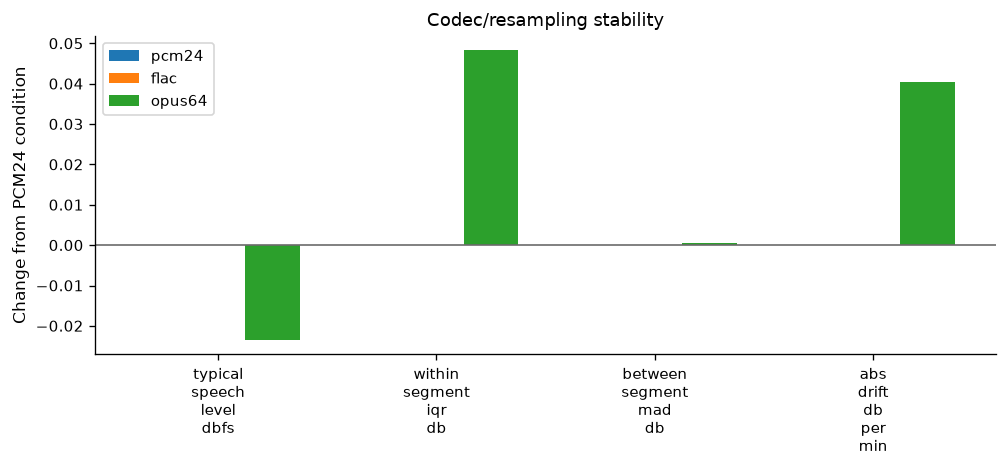

,layer,check,passed,observed,required,action_if_failed,blocking
0,codec,qgain_typical_speech_level_dbfs,True,0.0235,<=0.5,qualify codec dependence,True
1,codec,qgain_within_segment_iqr_db,True,0.0482,<=0.5,qualify codec dependence,True
2,codec,qgain_between_segment_mad_db,True,0.0005,<=0.5,qualify codec dependence,True
3,codec,qgain_abs_drift_db_per_min,True,0.0405,<=1.0,qualify codec dependence,True
4,codec,roundtrip commands completed,True,[],0 errors,repair local codec support,True


In [8]:
codec_rows = []
codec_errors = []
if RUN_CODEC_ROUNDTRIP:
    ffmpeg, ffprobe = shutil.which("ffmpeg"), shutil.which("ffprobe")
    with TemporaryDirectory() as temporary:
        temporary = Path(temporary)
        source_wav = temporary / "source.wav"
        sf.write(source_wav, base_waveform, FS, subtype="PCM_24")
        conditions = {
            "pcm24": source_wav,
            "flac": temporary / "roundtrip.flac",
            "opus64": temporary / "roundtrip.webm",
        }
        commands = [
            [ffmpeg, "-y", "-loglevel", "error", "-i", str(source_wav),
             "-c:a", "flac", str(conditions["flac"])],
            [ffmpeg, "-y", "-loglevel", "error", "-i", str(source_wav),
             "-c:a", "libopus", "-b:a", "64k", str(conditions["opus64"])],
        ]
        for command in commands:
            completed = subprocess.run(command, capture_output=True, text=True)
            if completed.returncode:
                codec_errors.append(completed.stderr)
        for condition, path in conditions.items():
            views = decode_audio_views(
                path, ffmpeg=ffmpeg, ffprobe=ffprobe, analysis_rate=FS
            )
            result = extract_qgain(
                views.analysis_16k, FS, strict_speech=synthetic_intervals,
                logical_recording_id=condition,
            ).recording
            codec_rows.append({"condition": condition, **{
                feature: result[feature] for feature in ANALYSIS_FEATURES
            }})
codec_roundtrip = pd.DataFrame(codec_rows)
if len(codec_roundtrip):
    reference = codec_roundtrip.set_index("condition").loc["pcm24"]
    codec_delta = codec_roundtrip.copy()
    for feature in ANALYSIS_FEATURES:
        codec_delta[feature] = codec_roundtrip[feature] - reference[feature]
    tolerance = {
        "qgain_typical_speech_level_dbfs": 0.50,
        "qgain_within_segment_iqr_db": 0.50,
        "qgain_between_segment_mad_db": 0.50,
        "qgain_abs_drift_db_per_min": 1.00,
    }
    codec_checks = validation_frame([
        ValidationCheck("codec", feature,
                        np.nanmax(np.abs(codec_delta[feature])) <= limit,
                        f"{np.nanmax(np.abs(codec_delta[feature])):.4f}",
                        f"<={limit}", "qualify codec dependence")
        for feature, limit in tolerance.items()
    ] + [
        ValidationCheck("codec", "roundtrip commands completed",
                        not codec_errors, str(codec_errors), "0 errors",
                        "repair local codec support")
    ])
else:
    codec_delta = pd.DataFrame()
    codec_checks = validation_frame([
        ValidationCheck("codec", "roundtrip completed", False, "NOT RUN",
                        "completed", "enable codec validation")
    ])
save_table_bundle(codec_roundtrip, TABLES, "qgain_v31_codec_roundtrip")
save_table_bundle(codec_delta, TABLES, "qgain_v31_codec_deltas")
save_table_bundle(codec_checks, TABLES, "qgain_v31_codec_checks")

if len(codec_delta):
    fig, ax = plt.subplots(figsize=(8.5, 4.0))
    display_features = list(ANALYSIS_FEATURES)
    positions = np.arange(len(display_features))
    width = 0.25
    for index, condition in enumerate(codec_delta["condition"]):
        values = codec_delta.loc[
            codec_delta["condition"].eq(condition), display_features
        ].iloc[0].to_numpy(float)
        ax.bar(positions + (index-1)*width, values, width=width, label=condition)
    ax.axhline(0, color=OKABE_ITO["grey"], linewidth=1)
    ax.set(xticks=positions,
           xticklabels=[name.replace("qgain_", "").replace("_", "\n")
                        for name in display_features],
           ylabel="Change from PCM24 condition",
           title="Codec/resampling stability")
    ax.legend()
    fig.tight_layout()
    save_publication_figure(
        fig, FIGURES, "figure_qgain_codec_stability",
        caption=("QGAIN v3.1 deterministic codec/resampling stability against "
                 "a PCM24 reference. Absolute-unit tolerances are prespecified."),
        alt_text="Grouped bars show feature changes after FLAC and Opus round trips.",
    )
    plt.show()
display(codec_checks)


## 8. Segment-support and boundary robustness


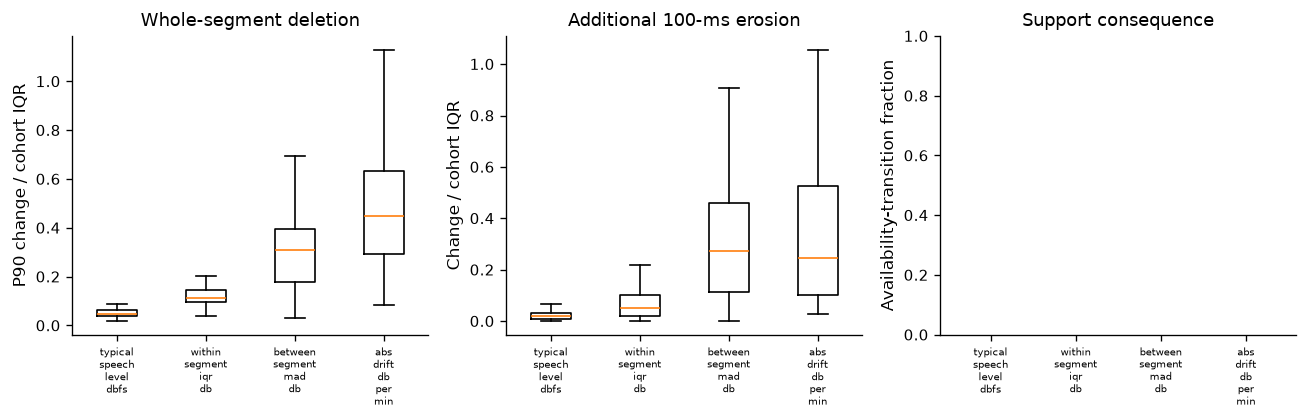

,layer,check,passed,observed,required,action_if_failed,blocking
0,robustness,one deletion summary per recording-feature,True,240,unique,repair weighting,True
1,boundary,all four features audited,True,"['qgain_abs_drift_db_per_min', 'qgain_between_...","['qgain_typical_speech_level_dbfs', 'qgain_wit...",repair boundary audit,True
2,robustness,no robustness extraction errors,True,0,0,resolve errors,True


In [9]:
robustness_rows, boundary_rows, robustness_errors = [], [], []
if RUN_COHORT_EXTRACTION and len(recording_table):
    available_ids = recording_table["logical_recording_id"].astype(str).tolist()
    selected_ids = available_ids[:min(MAX_ROBUSTNESS_RECORDINGS, len(available_ids))]
    recording_lookup = frozen["recordings"].set_index("logical_recording_id")
    for recording_id in selected_ids:
        try:
            row = recording_lookup.loc[recording_id]
            views = decode_audio_views(
                media_path_for(row), ffmpeg=shutil.which("ffmpeg"),
                ffprobe=shutil.which("ffprobe"), analysis_rate=FS,
            )
            intervals = intervals_for(recording_id)
            reference = extract_qgain(
                views.analysis_16k, FS, strict_speech=intervals,
                logical_recording_id=recording_id,
            ).recording
            if len(intervals) >= 2:
                for deleted_index in range(len(intervals)):
                    reduced = intervals[:deleted_index] + intervals[deleted_index+1:]
                    alternative = extract_qgain(
                        views.analysis_16k, FS, strict_speech=reduced,
                        logical_recording_id=recording_id,
                    ).recording
                    for feature in ANALYSIS_FEATURES:
                        robustness_rows.append({
                            "logical_recording_id": recording_id,
                            "deleted_segment_index": deleted_index,
                            "feature": feature,
                            "reference": reference[feature],
                            "alternative": alternative[feature],
                            "absolute_change": (
                                abs(alternative[feature]-reference[feature])
                                if np.isfinite(alternative[feature])
                                and np.isfinite(reference[feature]) else np.nan
                            ),
                            "availability_changed": (
                                np.isfinite(alternative[feature])
                                != np.isfinite(reference[feature])
                            ),
                        })
            eroded = extract_qgain(
                views.analysis_16k, FS, strict_speech=intervals,
                logical_recording_id=recording_id, guard_ms=300.0,
            ).recording
            for feature in ANALYSIS_FEATURES:
                boundary_rows.append({
                    "logical_recording_id": recording_id,
                    "feature": feature,
                    "reference": reference[feature],
                    "eroded": eroded[feature],
                    "absolute_change": (
                        abs(eroded[feature]-reference[feature])
                        if np.isfinite(eroded[feature])
                        and np.isfinite(reference[feature]) else np.nan
                    ),
                    "availability_changed": (
                        np.isfinite(eroded[feature])
                        != np.isfinite(reference[feature])
                    ),
                })
        except Exception as exc:
            robustness_errors.append({
                "logical_recording_id": recording_id, "message": str(exc)
            })
segment_deletion = pd.DataFrame(robustness_rows)
boundary_sensitivity = pd.DataFrame(boundary_rows)
robustness_error_table = pd.DataFrame(robustness_errors)

if len(segment_deletion):
    deletion_summary = (
        segment_deletion.groupby(["logical_recording_id", "feature"], as_index=False)
        .agg(delete_one_p90=("absolute_change", lambda x: x.quantile(0.90)),
             availability_transition_fraction=("availability_changed", "mean"))
    )
    boundary_summary = (
        boundary_sensitivity.groupby("feature", as_index=False)
        .agg(median_absolute_change=("absolute_change", "median"),
             p90_absolute_change=("absolute_change", lambda x: x.quantile(0.90)),
             availability_transition_fraction=("availability_changed", "mean"))
    )
    robustness_checks = validation_frame([
        ValidationCheck("robustness", "one deletion summary per recording-feature",
                        not deletion_summary[[
                            "logical_recording_id", "feature"
                        ]].duplicated().any(),
                        str(len(deletion_summary)), "unique", "repair weighting"),
        ValidationCheck("boundary", "all four features audited",
                        set(boundary_summary["feature"]) == set(ANALYSIS_FEATURES),
                        str(boundary_summary["feature"].tolist()),
                        str(list(ANALYSIS_FEATURES)), "repair boundary audit"),
        ValidationCheck("robustness", "no robustness extraction errors",
                        robustness_error_table.empty,
                        str(len(robustness_error_table)), "0", "resolve errors"),
    ])
else:
    deletion_summary, boundary_summary = pd.DataFrame(), pd.DataFrame()
    robustness_checks = validation_frame([
        ValidationCheck("robustness", "cohort robustness completed", False,
                        "NOT RUN", "completed", "run cohort extraction")
    ])
for frame, name in [
    (segment_deletion, "qgain_v31_segment_delete_one_long"),
    (deletion_summary, "qgain_v31_segment_delete_one_by_recording"),
    (boundary_sensitivity, "qgain_v31_boundary_erosion_by_recording"),
    (boundary_summary, "qgain_v31_boundary_erosion_population"),
    (robustness_error_table, "qgain_v31_robustness_errors"),
    (robustness_checks, "qgain_v31_robustness_checks"),
]:
    save_table_bundle(frame, TABLES, name)

if len(segment_deletion):
    cohort_iqr = {
        feature: (
            recording_table[feature].quantile(0.75)
            - recording_table[feature].quantile(0.25)
        ) for feature in ANALYSIS_FEATURES
    }
    fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.6))
    deletion_plot = []
    boundary_plot = []
    for feature in ANALYSIS_FEATURES:
        scale = cohort_iqr[feature]
        deletion_plot.append(
            deletion_summary.loc[
                deletion_summary["feature"].eq(feature), "delete_one_p90"
            ] / scale if np.isfinite(scale) and scale > 0 else pd.Series(dtype=float)
        )
        boundary_plot.append(
            boundary_sensitivity.loc[
                boundary_sensitivity["feature"].eq(feature), "absolute_change"
            ] / scale if np.isfinite(scale) and scale > 0 else pd.Series(dtype=float)
        )
    labels = [name.replace("qgain_", "").replace("_", "\n")
              for name in ANALYSIS_FEATURES]
    n_features = len(ANALYSIS_FEATURES)
    axes[0].boxplot(deletion_plot, showfliers=False)
    axes[0].set_xticks(range(1, n_features + 1), labels=labels)
    axes[0].set(ylabel="P90 change / cohort IQR", title="Whole-segment deletion")
    axes[1].boxplot(boundary_plot, showfliers=False)
    axes[1].set_xticks(range(1, n_features + 1), labels=labels)
    axes[1].set(ylabel="Change / cohort IQR", title="Additional 100-ms erosion")
    availability = boundary_sensitivity.groupby("feature")["availability_changed"].mean().reindex(ANALYSIS_FEATURES)
    axes[2].bar(range(n_features), availability, color=OKABE_ITO["purple"])
    axes[2].set(xticks=range(n_features), xticklabels=labels, ylim=(0, 1),
                ylabel="Availability-transition fraction",
                title="Support consequence")
    for ax in axes:
        ax.tick_params(axis="x", labelsize=6)
    fig.tight_layout()
    save_publication_figure(
        fig, FIGURES, "figure_qgain_support_boundary_robustness",
        caption=("QGAIN v3.1 clustered support and boundary robustness. "
                 "Whole-segment deletion and additional 100-ms erosion are "
                 "reported in empirical-IQR units only for cross-feature display; "
                 "absolute-unit tables and availability transitions are retained."),
        alt_text=("Three panels show segment-deletion sensitivity, boundary "
                  "sensitivity, and availability transitions for four features."),
    )
    plt.show()
display(robustness_checks)


## 9. Empirical distributions, availability, and feature structure


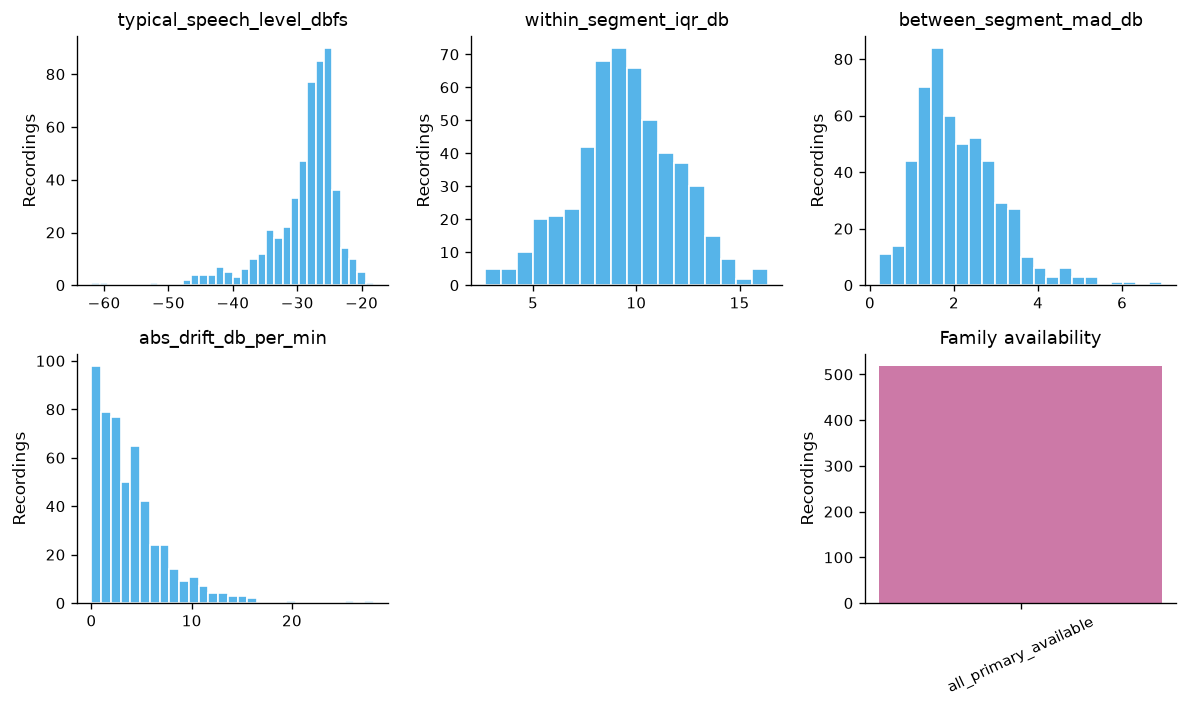

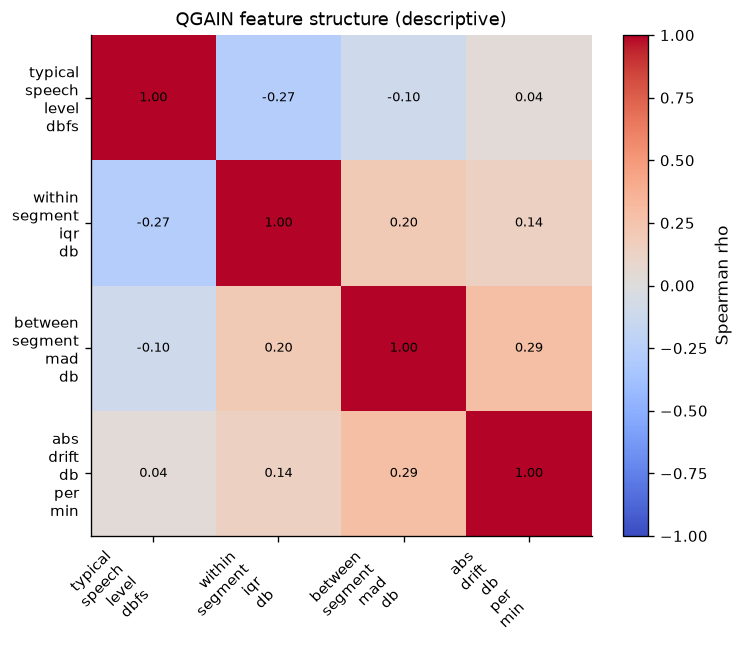

,feature,recording_count,available_count,available_fraction,median,q25,q75,status_counts_json
0,qgain_typical_speech_level_dbfs,519,519,1.0,-27.376117,-30.713135,-25.449886,"{""measured"": 519}"
1,qgain_within_segment_iqr_db,519,519,1.0,9.419411,8.028174,11.188531,"{""measured"": 519}"
2,qgain_between_segment_mad_db,519,519,1.0,1.957771,1.399745,2.683379,"{""measured"": 519}"
3,qgain_abs_drift_db_per_min,519,519,1.0,3.041115,1.291863,5.254722,"{""measured"": 519}"


In [10]:
empirical_summary, empirical_correlations = pd.DataFrame(), pd.DataFrame()
if RUN_COHORT_EXTRACTION and len(recording_table):
    summary_rows = []
    for feature in ANALYSIS_FEATURES:
        values = pd.to_numeric(recording_table[feature], errors="coerce")
        finite = values[np.isfinite(values)]
        summary_rows.append({
            "feature": feature,
            "recording_count": len(recording_table),
            "available_count": len(finite),
            "available_fraction": len(finite)/len(recording_table),
            "median": finite.median() if len(finite) else np.nan,
            "q25": finite.quantile(0.25) if len(finite) else np.nan,
            "q75": finite.quantile(0.75) if len(finite) else np.nan,
            "status_counts_json": json.dumps(
                recording_table[f"{feature}_status"].value_counts(
                    dropna=False
                ).to_dict(), sort_keys=True
            ),
        })
    empirical_summary = pd.DataFrame(summary_rows)
    empirical_correlations = recording_table[
        list(ANALYSIS_FEATURES)
    ].corr(method="spearman", min_periods=20)
    save_table_bundle(empirical_summary, TABLES, "qgain_v31_empirical_summary")
    save_table_bundle(
        empirical_correlations.reset_index(),
        TABLES, "qgain_v31_spearman_feature_correlations"
    )

    fig, axes = plt.subplots(2, 3, figsize=(10.0, 6.0))
    for ax, feature in zip(axes.flat, ANALYSIS_FEATURES):
        values = pd.to_numeric(recording_table[feature], errors="coerce").dropna()
        ax.hist(values, bins="fd" if len(values) > 1 else 1,
                color=OKABE_ITO["sky"], edgecolor="white")
        ax.set(title=feature.replace("qgain_", ""), ylabel="Recordings")
    status = recording_table["qgain_family_status"].value_counts()
    axes.flat[-1].bar(status.index, status.values, color=OKABE_ITO["purple"])
    axes.flat[-1].tick_params(axis="x", rotation=25)
    axes.flat[-1].set(title="Family availability", ylabel="Recordings")
    axes.flat[-2].axis("off")
    fig.tight_layout()
    save_publication_figure(
        fig, FIGURES, "figure_qgain_empirical_distributions",
        caption=("Empirical QGAIN v3.1 feature distributions and primary-feature "
                 "availability in the frozen cohort."),
        alt_text="Four feature histograms and one family-availability bar chart.",
    )
    plt.show()

    fig, ax = plt.subplots(figsize=(6.4, 5.4))
    matrix = empirical_correlations.to_numpy(float)
    image = ax.imshow(matrix, vmin=-1, vmax=1, cmap="coolwarm")
    labels = [name.replace("qgain_", "").replace("_", "\n")
              for name in ANALYSIS_FEATURES]
    n_features = len(ANALYSIS_FEATURES)
    ax.set_xticks(range(n_features), labels=labels, rotation=45, ha="right")
    ax.set_yticks(range(n_features), labels=labels)
    for row in range(n_features):
        for column in range(n_features):
            value = matrix[row, column]
            ax.text(column, row,
                    "NA" if not np.isfinite(value) else f"{value:.2f}",
                    ha="center", va="center", fontsize=8)
    fig.colorbar(image, ax=ax, label="Spearman rho")
    ax.set_title("QGAIN feature structure (descriptive)")
    fig.tight_layout()
    save_publication_figure(
        fig, FIGURES, "figure_qgain_feature_structure",
        caption=("Pairwise-available Spearman correlations among QGAIN v3.1 "
                 "features. Correlation is descriptive and does not justify a scalar score."),
        alt_text="Annotated heatmap of pairwise feature correlations.",
    )
    plt.show()
    empirical_checks = validation_frame([
        ValidationCheck("empirical", "one row per analysis feature",
                        len(empirical_summary) == len(ANALYSIS_FEATURES),
                        str(len(empirical_summary)), "4", "repair summary"),
        ValidationCheck("empirical", "availability explicitly reported",
                        empirical_summary["available_fraction"].between(0, 1).all(),
                        "checked", "[0,1]", "repair missingness accounting"),
    ])
else:
    empirical_checks = validation_frame([
        ValidationCheck("empirical", "cohort characterization", False,
                        "NOT RUN", "completed", "run cohort extraction")
    ])
display(empirical_summary if len(empirical_summary) else empirical_checks)


## 10. Negative-result audit: excluded local-transition detector

QGAIN v3.0 proposed a frame-local transition rate. Cohort validation
showed that ordinary phonetic and prosodic changes generated pervasive
candidates, violating the intended interpretation as occasional
acquisition-gain steps. QGAIN v3.1 therefore excludes this quantity from
the feature registry, analysis table, correlations, freeze gates, and
central export. The ledger is retained only to make that decision
reproducible.


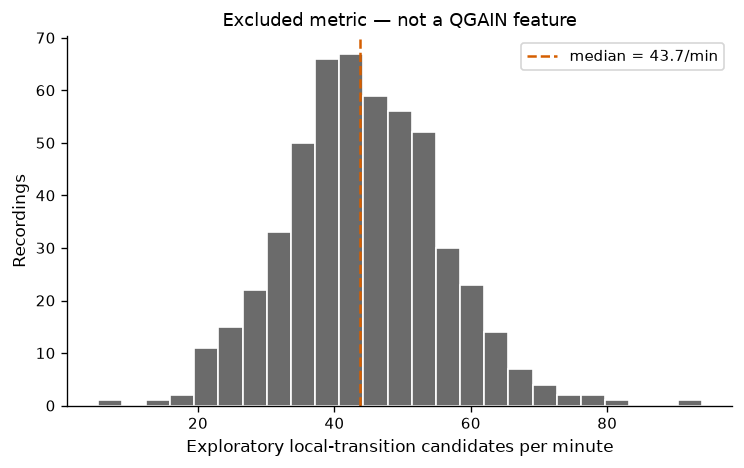

,candidate_metric,analysis_status,recording_count,total_candidate_count,recordings_with_candidates_fraction,median_candidates_per_min,q25_candidates_per_min,q75_candidates_per_min,decision_basis
0,frame_local_transition_rate,REJECTED_NOT_AN_ANALYSIS_FEATURE,519,8412,1.0,43.697479,37.028248,51.748934,Pervasive real-speech candidates were inconsis...


,layer,check,passed,observed,required,action_if_failed,blocking
0,negative_result,rejected metric absent from analysis registry,True,absent,absent,repair registry,True
1,negative_result,rejected metric absent from analysis table,True,absent,absent,repair analysis export,True
2,negative_result,exploratory status is explicit,True,checked,all explicitly rejected,repair audit status,True


In [11]:
excluded_metric_audit = pd.DataFrame()
if RUN_COHORT_EXTRACTION and len(recording_table):
    rates = pd.to_numeric(
        recording_table[
            "qgain_exploratory_local_transition_rate_per_min"
        ],
        errors="coerce",
    )
    counts = pd.to_numeric(
        recording_table[
            "qgain_exploratory_local_transition_count"
        ],
        errors="coerce",
    )
    finite_rates = rates[np.isfinite(rates)]
    excluded_metric_audit = pd.DataFrame([{
        "candidate_metric": "frame_local_transition_rate",
        "analysis_status": "REJECTED_NOT_AN_ANALYSIS_FEATURE",
        "recording_count": len(recording_table),
        "total_candidate_count": int(counts.fillna(0).sum()),
        "recordings_with_candidates_fraction": float(counts.gt(0).mean()),
        "median_candidates_per_min": (
            float(finite_rates.median()) if len(finite_rates) else np.nan
        ),
        "q25_candidates_per_min": (
            float(finite_rates.quantile(0.25)) if len(finite_rates) else np.nan
        ),
        "q75_candidates_per_min": (
            float(finite_rates.quantile(0.75)) if len(finite_rates) else np.nan
        ),
        "decision_basis": (
            "Pervasive real-speech candidates were inconsistent with "
            "occasional acquisition-gain steps and visually followed "
            "ordinary speech-level transitions."
        ),
    }])
    exclusion_checks = validation_frame([
        ValidationCheck(
            "negative_result",
            "rejected metric absent from analysis registry",
            "qgain_sustained_step_rate_per_min" not in ANALYSIS_FEATURES,
            "absent", "absent", "repair registry",
        ),
        ValidationCheck(
            "negative_result",
            "rejected metric absent from analysis table",
            not any(
                "transition" in column or "step" in column
                for column in analysis_feature_table.columns
            ),
            "absent", "absent", "repair analysis export",
        ),
        ValidationCheck(
            "negative_result",
            "exploratory status is explicit",
            recording_table[
                "qgain_exploratory_local_transition_status"
            ].eq(
                "rejected_v3_0_false_positive_burden_not_analysis"
            ).all(),
            "checked", "all explicitly rejected", "repair audit status",
        ),
    ])
    save_table_bundle(
        excluded_metric_audit, TABLES,
        "qgain_v31_excluded_local_transition_metric"
    )
    save_table_bundle(
        exclusion_checks, TABLES, "qgain_v31_exclusion_checks"
    )

    fig, ax = plt.subplots(figsize=(6.3, 4.0))
    ax.hist(
        finite_rates,
        bins="fd" if len(finite_rates) > 1 else 1,
        color=OKABE_ITO["grey"],
        edgecolor="white",
    )
    ax.axvline(
        finite_rates.median(),
        color=OKABE_ITO["vermillion"],
        linestyle="--",
        label=f"median = {finite_rates.median():.1f}/min",
    )
    ax.set(
        xlabel="Exploratory local-transition candidates per minute",
        ylabel="Recordings",
        title="Excluded metric — not a QGAIN feature",
    )
    ax.legend()
    fig.tight_layout()
    save_publication_figure(
        fig, FIGURES, "figure_qgain_excluded_transition_diagnostic",
        caption=("Negative-result audit for the QGAIN v3.0 local-transition "
                 "candidate metric. Its pervasive response in real speech "
                 "motivated exclusion from QGAIN v3.1 analysis."),
        alt_text=("Histogram of an explicitly rejected local-transition "
                  "candidate rate, labeled as not a QGAIN feature."),
    )
    plt.show()
else:
    exclusion_checks = validation_frame([
        ValidationCheck(
            "negative_result", "excluded-metric audit completed",
            False, "NOT RUN", "completed", "run cohort extraction"
        )
    ])
display(excluded_metric_audit)
display(exclusion_checks)


## 11. Label-blind reviewer gallery

Recordings are selected algorithmically from feature quantiles and extremes.
The gallery is for scientific review, not threshold tuning, and contains
only waveform support, frame-level measurements, and segment-level
summaries used by the four-feature profile.


In [12]:
gallery_index = pd.DataFrame()

def choose_gallery(table):
    candidates = []
    for feature in ANALYSIS_FEATURES:
        local = table.loc[pd.to_numeric(table[feature], errors="coerce").notna()]
        if not len(local):
            continue
        for quantile in [0.05, 0.50, 0.95]:
            target = local[feature].quantile(quantile)
            index = (local[feature]-target).abs().idxmin()
            candidates.append((
                local.loc[index, "logical_recording_id"],
                f"{feature}_q{int(100*quantile):02d}",
            ))
    frame = pd.DataFrame(candidates, columns=[
        "logical_recording_id", "selection_reason"
    ])
    return frame.groupby("logical_recording_id", as_index=False)[
        "selection_reason"
    ].agg(";".join).head(12)


def plot_gallery_recording(recording_id, reason):
    row = frozen["recordings"].set_index("logical_recording_id").loc[str(recording_id)]
    views = decode_audio_views(
        media_path_for(row), ffmpeg=shutil.which("ffmpeg"),
        ffprobe=shutil.which("ffprobe"), analysis_rate=FS,
    )
    extraction = extract_qgain(
        views.analysis_16k, FS, strict_speech=intervals_for(recording_id),
        logical_recording_id=recording_id,
    )
    time = np.arange(len(views.analysis_16k))/FS
    stride = max(1, len(time)//12000)
    fig, axes = plt.subplots(3, 1, figsize=(10.0, 6.8), sharex=True)
    axes[0].plot(time[::stride], views.analysis_16k[::stride],
                 color=OKABE_ITO["grey"], linewidth=0.5)
    for interval in guarded_speech_intervals(
        intervals_for(recording_id), len(time)/FS
    ):
        axes[0].axvspan(interval.start_sec, interval.end_sec,
                        color=OKABE_ITO["sky"], alpha=0.20)
    axes[0].set(ylabel="Amplitude", title=f"{recording_id} - {reason}")
    frame = extraction.frame_ledger
    axes[1].scatter(frame["frame_mid_sec"], frame["ac_rms_dbfs"],
                    s=4, alpha=0.45, color=OKABE_ITO["blue"])
    axes[1].set(ylabel="40-ms AC level (dBFS)")
    segment = extraction.segment_ledger.loc[
        extraction.segment_ledger["usable_segment"].astype(bool)
    ]
    axes[2].plot(segment["segment_mid_sec"],
                 segment["segment_level_median_dbfs"], "o-",
                 color=OKABE_ITO["orange"], label="segment median")
    axes[2].set(xlabel="Original recording time (s)",
                ylabel="Segment level (dBFS)")
    axes[2].legend(fontsize=8)
    fig.tight_layout()
    save_publication_figure(
        fig, GALLERY, f"qgain_gallery_{recording_id}",
        caption=(f"Label-blind QGAIN audit gallery: {recording_id}; "
                 f"selection={reason}."),
        alt_text=("Waveform with guarded speech, frame-level AC-RMS trajectory, "
                  "and segment-median level trajectory."),
        dpi=300,
    )
    plt.close(fig)


if BUILD_GALLERY and RUN_COHORT_EXTRACTION and len(recording_table):
    gallery_index = choose_gallery(recording_table)
    for row in gallery_index.itertuples(index=False):
        try:
            plot_gallery_recording(str(row.logical_recording_id),
                                   str(row.selection_reason))
        except Exception as exc:
            gallery_index.loc[
                gallery_index["logical_recording_id"].eq(row.logical_recording_id),
                "gallery_error",
            ] = str(exc)
    save_table_bundle(gallery_index, GALLERY, "qgain_gallery_index")
else:
    gallery_index = pd.DataFrame([{
        "logical_recording_id": pd.NA, "selection_reason": "NOT RUN"
    }])
display(gallery_index)


,logical_recording_id,selection_reason
0,CAPT0000035_272_1_20230420_240_PSG_BAMBOO,qgain_typical_speech_level_dbfs_q95
1,CAPT0000045_272_4_20240828_240_PSG_BAMBOO,qgain_between_segment_mad_db_q05
2,CAPT0000124_272_1_20240806_240_PSG_BAMBOO,qgain_typical_speech_level_dbfs_q50
3,CAPT0000125_272_1_20240812_240_PSG_BAMBOO,qgain_within_segment_iqr_db_q50
4,CAPT0000135_272_1_20241111_240_PSG_BAMBOO,qgain_between_segment_mad_db_q50
5,CAPT0000163_272_2_20250422_240_PSG_BAMBOO,qgain_typical_speech_level_dbfs_q05
6,TIBD123_270_1_20250820_240_PSG_BAMBOO,qgain_between_segment_mad_db_q95
7,TIBD31_270_2_20220525_240_PSG_BAMBOO,qgain_within_segment_iqr_db_q95
8,TIBD45_1003_1_20220825_240_PSG_BAMBOO,qgain_abs_drift_db_per_min_q50
9,TIBD79_1003_1_20230621_240_PSG_BAMBOO,qgain_within_segment_iqr_db_q05


## 12. Scientific gates, immutable freeze, and central-table export


In [13]:
if RUN_PACKAGE_TESTS:
    completed = subprocess.run(
        [sys.executable, "-m", "pytest", "tests/test_qgain_v31.py", "-q"],
        cwd=ROOT, capture_output=True, text=True,
    )
    package_test_passed = completed.returncode == 0
    package_test_observed = (
        completed.stdout + "\n" + completed.stderr
    ).strip()[-1200:]
else:
    package_test_passed = bool(PACKAGE_TESTS_CONFIRMED)
    package_test_observed = (
        "confirmed externally" if PACKAGE_TESTS_CONFIRMED
        else "NOT RUN"
    )

review_passed = (
    QGAIN_REVIEW_DECISION == "ACCEPT_QGAIN_V31"
    and bool(QGAIN_REVIEWER.strip())
    and bool(QGAIN_REVIEW_RATIONALE.strip())
    and len(gallery_index)
    and not gallery_index.get(
        "gallery_error", pd.Series(dtype=object)
    ).notna().any()
)
layer_summary = validation_frame([
    ValidationCheck("technical", "package tests", package_test_passed,
                    package_test_observed, "all pass", "repair package/tests"),
    ValidationCheck("technical", "registry contract",
                    gate_passed(registry_checks),
                    f"{int(registry_checks['passed'].sum())}/{len(registry_checks)}",
                    "all pass", "repair registry"),
    ValidationCheck("technical", "formula/transform controls",
                    gate_passed(formula_checks),
                    f"{int(formula_checks['passed'].sum())}/{len(formula_checks)}",
                    "all pass", "repair estimator"),
    ValidationCheck("input", "frozen input contract",
                    gate_passed(input_checks),
                    f"{int(input_checks['passed'].sum())}/{len(input_checks)}",
                    "all pass", "repair frozen inputs"),
    ValidationCheck("extraction", "cohort extraction contract",
                    gate_passed(extraction_checks),
                    f"{int(extraction_checks['passed'].sum())}/{len(extraction_checks)}",
                    "all pass", "resolve extraction"),
    ValidationCheck("scientific", "mechanism/discriminant controls",
                    gate_passed(mechanism_checks),
                    f"{int(mechanism_checks['passed'].sum())}/{len(mechanism_checks)}",
                    "all pass", "revise estimator/claims"),
    ValidationCheck("scientific", "floor-censoring calibration",
                    gate_passed(floor_checks),
                    f"{int(floor_checks['passed'].sum())}/{len(floor_checks)}",
                    "all pass", "repair floor policy"),
    ValidationCheck("scientific", "codec stability",
                    gate_passed(codec_checks),
                    f"{int(codec_checks['passed'].sum())}/{len(codec_checks)}",
                    "all pass", "qualify codec dependence"),
    ValidationCheck("scientific", "support/boundary robustness",
                    gate_passed(robustness_checks),
                    f"{int(robustness_checks['passed'].sum())}/{len(robustness_checks)}",
                    "all pass", "repair robustness assessment"),
    ValidationCheck("scientific", "rejected-metric exclusion",
                    gate_passed(exclusion_checks),
                    f"{int(exclusion_checks['passed'].sum())}/{len(exclusion_checks)}",
                    "all pass", "repair analysis/audit separation"),
    ValidationCheck("empirical", "cohort distributions/availability",
                    gate_passed(empirical_checks),
                    f"{int(empirical_checks['passed'].sum())}/{len(empirical_checks)}",
                    "all pass", "complete empirical characterization"),
    ValidationCheck("review", "gallery reviewed and accepted",
                    review_passed, QGAIN_REVIEW_DECISION,
                    "ACCEPT_QGAIN_V31 with reviewer/rationale",
                    "complete scientific review"),
    ValidationCheck("integration", "central registry/CLI approved",
                    PACKAGE_INTEGRATION_APPROVED,
                    str(PACKAGE_INTEGRATION_APPROVED),
                    "True after measurement freeze",
                    "integrate downstream", blocking=False),
])
save_table_bundle(layer_summary, TABLES, "qgain_v31_gate_summary")
display(layer_summary)

all_blocking_layers_pass = gate_passed(layer_summary)
freeze_requested_safely = (
    PUBLISH_AND_FREEZE_QGAIN_V31 and all_blocking_layers_pass
)
manifest = {
    "measurement_version": MEASUREMENT_VERSION,
    "candidate_only": not freeze_requested_safely,
    "all_blocking_layers_pass": all_blocking_layers_pass,
    "publish_and_freeze_requested": PUBLISH_AND_FREEZE_QGAIN_V31,
    "analysis_features": list(ANALYSIS_FEATURES),
    "parameters": PARAMETERS.to_dict(),
    "implementation_sha256": sha256_file(
        ROOT / "src/paper1_qc/qgain.py"
    ),
    "gate_table_sha256": sha256_file(
        TABLES / "qgain_v31_gate_summary.csv"
    ),
    "excluded_metric": {
        "name": "frame_local_transition_rate",
        "status": "rejected_not_an_analysis_feature",
        "basis_table": "tables/qgain_v31_excluded_local_transition_metric.csv",
    },
    "scientific_review": {
        "decision": QGAIN_REVIEW_DECISION,
        "reviewer": QGAIN_REVIEWER,
        "rationale": QGAIN_REVIEW_RATIONALE,
    },
}
if PUBLISH_AND_FREEZE_QGAIN_V31 and not all_blocking_layers_pass:
    raise RuntimeError(
        "QGAIN freeze requested, but one or more blocking layers failed."
    )
frozen_root = (
    MAIN_OUTPUTS / "02_FEATURE_FREEZE" / "gain_dynamics"
    / MEASUREMENT_VERSION
)
if freeze_requested_safely:
    manifest["stage_file_sha256"] = {
        str(path.relative_to(STAGE)): sha256_file(path)
        for path in sorted(STAGE.rglob("*"))
        if path.is_file()
        and path.name not in {
            "qgain_v31_candidate_manifest.json",
            "qgain_v31_frozen_manifest.json",
        }
    }
    write_json(manifest, AUDIT / "qgain_v31_frozen_manifest.json")
    temporary_frozen_root = frozen_root.with_name(
        f".{frozen_root.name}.copying"
    )
    if frozen_root.exists() or temporary_frozen_root.exists():
        raise FileExistsError(
            f"Refusing to overwrite existing QGAIN freeze: {frozen_root}"
        )
    frozen_root.parent.mkdir(parents=True, exist_ok=True)
    shutil.copytree(STAGE, temporary_frozen_root)
    temporary_frozen_root.replace(frozen_root)
    display(Markdown(
        f"## FROZEN - QGAIN v3.1 passed every blocking layer\n\n"
        f"Immutable snapshot: `{frozen_root}`"
    ))
else:
    write_json(manifest, AUDIT / "qgain_v31_candidate_manifest.json")
    display(Markdown(
        "## CANDIDATE ONLY - inspect all gates; publication/freeze is blocked"
    ))


,layer,check,passed,observed,required,action_if_failed,blocking
0,technical,package tests,True,[32m.[0m[32m.[0m[32m.[0m[32m.[0m[32m....,all pass,repair package/tests,True
1,technical,registry contract,True,3/3,all pass,repair registry,True
2,technical,formula/transform controls,True,2/2,all pass,repair estimator,True
3,input,frozen input contract,True,3/3,all pass,repair frozen inputs,True
4,extraction,cohort extraction contract,True,5/5,all pass,resolve extraction,True
5,scientific,mechanism/discriminant controls,True,3/3,all pass,revise estimator/claims,True
6,scientific,floor-censoring calibration,True,2/2,all pass,repair floor policy,True
7,scientific,codec stability,True,5/5,all pass,qualify codec dependence,True
8,scientific,support/boundary robustness,True,3/3,all pass,repair robustness assessment,True
9,scientific,rejected-metric exclusion,True,3/3,all pass,repair analysis/audit separation,True


## FROZEN - QGAIN v3.1 passed every blocking layer

Immutable snapshot: `C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\MAIN outputs\02_FEATURE_FREEZE\gain_dynamics\qgain-v3.1.0`

In [14]:
# Export the authoritative frozen recording table to MAIN outputs.
# Candidate runs skip cleanly; frozen runs refuse non-identical overwrite.
CENTRAL_FEATURE_TABLES = MAIN_OUTPUTS / "02_FEATURE_TABLES"
FROZEN_MANIFEST = frozen_root / "audit" / "qgain_v31_frozen_manifest.json"
SOURCE_TABLES = frozen_root / "tables"
SOURCE_FILES = [
    SOURCE_TABLES / "qgain_v31_analysis_features.csv",
    SOURCE_TABLES / "qgain_v31_analysis_features.parquet",
]

def export_frozen_qgain_table():
    if any(not path.exists() for path in SOURCE_FILES):
        raise FileNotFoundError(
            "Frozen QGAIN recording table bundle is incomplete."
        )
    frozen_csv = pd.read_csv(SOURCE_FILES[0])
    missing = [
        column for column in ["logical_recording_id", *ANALYSIS_FEATURES]
        if column not in frozen_csv
    ]
    if missing:
        raise ValueError(f"Frozen table lacks required columns: {missing}")
    if frozen_csv["logical_recording_id"].astype(str).duplicated().any():
        raise ValueError("Frozen QGAIN table contains duplicate recording IDs.")
    forbidden = [
        column for column in frozen_csv.columns
        if "step" in column.lower() or "transition" in column.lower()
    ]
    if forbidden:
        raise ValueError(
            f"Frozen analysis table contains rejected diagnostics: {forbidden}"
        )
    CENTRAL_FEATURE_TABLES.mkdir(parents=True, exist_ok=True)
    export_rows = []
    for source_path in SOURCE_FILES:
        destination = CENTRAL_FEATURE_TABLES / source_path.name
        source_hash = sha256_file(source_path)
        if destination.exists():
            if sha256_file(destination) != source_hash:
                raise FileExistsError(
                    f"Refusing to overwrite different central table: {destination}"
                )
            action = "already present and identical"
        else:
            shutil.copy2(source_path, destination)
            if sha256_file(destination) != source_hash:
                raise RuntimeError(f"Hash verification failed: {destination}")
            action = "copied and hash-verified"
        export_rows.append({
            "file": destination.name, "action": action,
            "rows": len(frozen_csv), "columns": len(frozen_csv.columns),
            "sha256": source_hash,
        })
    return pd.DataFrame(export_rows)


if FROZEN_MANIFEST.exists():
    display(export_frozen_qgain_table())
else:
    display(Markdown(
        "### Central export skipped\n\n"
        "This is the expected behavior for a candidate run. "
        "No unfrozen table was copied into `MAIN outputs/02_FEATURE_TABLES`."
    ))


,file,action,rows,columns,sha256
0,qgain_v31_analysis_features.csv,copied and hash-verified,519,27,b81bce7d268c8b7ec6890097b482fb7d62c6db8f87cf79...
1,qgain_v31_analysis_features.parquet,copied and hash-verified,519,27,f132861876b69c5f608da8060c4f74dbcfb07c155bd57c...
